In [62]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from IPython.display import Image
import operator

In [ ]:
class GameScore(TypedDict):
    game_scores: Annotated[list[float], operator.add] # reducer
    is_winner: bool
    average_score: float

In [ ]:
def is_winner(state: GameScore):
    return {
        "is_winner": sum(state['game_scores']) > 100
    }

def add_least_score(state: GameScore):
    return {
        'game_scores': [min(state['game_scores'])]
    }

def add_max_score(state: GameScore):
    return {
        'game_scores': [max(state['game_scores'])]
    }

def average_score(state: GameScore):
    state['average_score'] = sum(state['game_scores']) / len(state['game_scores'])
    return { # returning full state again create merge
        'average_score': state['average_score']
    }

In [65]:
def show_workflow_image(workflow: StateGraph) -> Image:
    return Image(workflow.get_graph().draw_mermaid_png())

In [71]:
# Graph
graph = StateGraph(GameScore)

# Nodes
graph.add_node("is_winner", is_winner)
graph.add_node("add_least_score", add_least_score)
graph.add_node("add_max_score", add_max_score)
graph.add_node("average_score", average_score)

# Edges
graph.add_edge(START, "is_winner")
graph.add_edge(START, "add_max_score")
graph.add_edge(START, "add_least_score")
graph.add_edge("is_winner", "average_score")
graph.add_edge("add_least_score", "average_score")
graph.add_edge("add_max_score", "average_score")
graph.add_edge("average_score", END)


In [72]:
workflow = graph.compile()

In [75]:
initial_state = GameScore(game_scores=[10, 20, 30, 40], is_winner=False, avergage_score=0.0)
final_state = workflow.invoke(initial_state)
print(final_state)

{'game_scores': [10, 20, 30, 40, 10, 40], 'is_winner': False, 'average_score': 25.0}


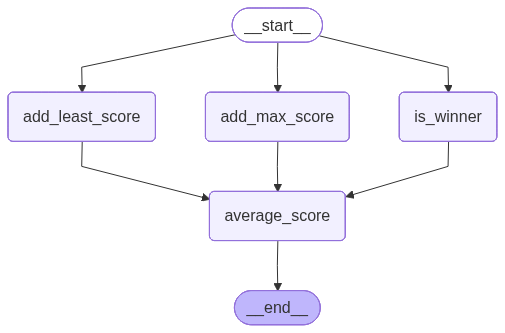

In [76]:
show_workflow_image(workflow)